In [206]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [207]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [208]:
y

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,

<Axes: xlabel='0', ylabel='1'>

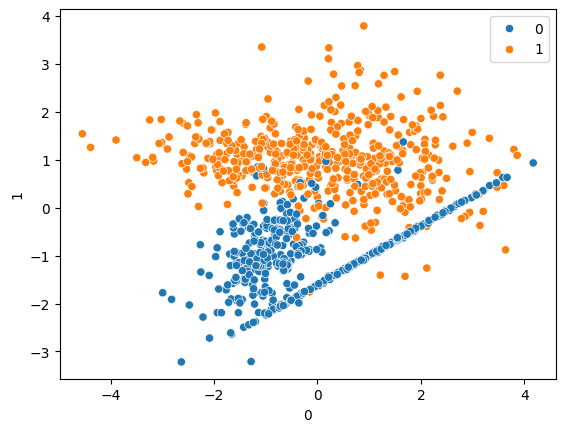

In [209]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [210]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.25,random_state=10)

In [211]:
from sklearn.svm import SVC
svc = SVC()

In [212]:
svc.fit(X_train,y_train)

SVC()

In [213]:
y_pred = svc.predict(X_test)

In [214]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true=y_test,y_pred=y_pred)) 
print(confusion_matrix(y_true=y_test,y_pred=y_pred))


              precision    recall  f1-score   support

           0       0.88      0.98      0.93       114
           1       0.98      0.89      0.93       136

    accuracy                           0.93       250
   macro avg       0.93      0.94      0.93       250
weighted avg       0.94      0.93      0.93       250

[[112   2]
 [ 15 121]]


In [215]:
svc1 = SVC(kernel="rbf")

In [222]:
svc1.fit(X_train,y_train)
y_pred = svc1.predict(X_test)


In [223]:
print(classification_report(y_true=y_test,y_pred=y_pred)) 
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       114
           1       0.98      0.89      0.93       136

    accuracy                           0.93       250
   macro avg       0.93      0.94      0.93       250
weighted avg       0.94      0.93      0.93       250

[[112   2]
 [ 15 121]]


In [221]:
svc2 = SVC(kernel="linear")
svc2.fit(X_train,y_train)
y_pred = svc2.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred)) 
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       114
           1       0.95      0.86      0.90       136

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.91      0.90      0.90       250

[[108   6]
 [ 19 117]]


In [ ]:
svc3 = SVC(kernel="poly")
svc3.fit(X_train,y_train)
y_pred = svc3.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred)) 
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       114
           1       0.98      0.89      0.93       136

    accuracy                           0.93       250
   macro avg       0.93      0.94      0.93       250
weighted avg       0.94      0.93      0.93       250

[[112   2]
 [ 15 121]]


In [232]:
params = {"C":[0.1,1,10,100,1000],
          "gamma":[1,.1,.01,.001,.0001],
          "kernel":['linear', 'poly', 'rbf', 'sigmoid']}

In [233]:
from sklearn.model_selection import GridSearchCV
grid= GridSearchCV(estimator=SVC(),param_grid=params,cv=5,verbose=3)

In [234]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.953 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.913 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.913 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.947 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.940 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.920 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.940 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.920 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.933 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.947 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rb

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             verbose=3)

In [235]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [236]:
y_pred = grid.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred)) 
print(confusion_matrix(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       114
           1       0.98      0.90      0.94       136

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[112   2]
 [ 13 123]]


In [ ]:
X = np.linspace(-5,5,100)
y = np.sqrt(100-X**2)

